# **EDA performed on dataset: simulated_transactions_seed_42.csv**

## Section 0 - Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/simulated/simulated_transactions_seed_42.csv")

df.head()

,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,e4fd6c34-d67,2026-01-19 09:59:35.248955,user_55,172.43,grocery,475287aa,PIN,-83.615968,174.348649,120.185.31.102,0
1,0cb5ee5c-62f,2026-01-18 11:55:15.356815,user_407,8.43,food,379d58f9,Biometric,20.500359,150.789724,107.109.217.82,0
2,39a0f145-a5b,2026-02-14 00:45:15.799367,user_142,1259.07,tech,bea29dfe,PIN,-87.864685,123.877867,145.56.170.82,0
3,052226b9-836,2026-01-16 11:40:03.965444,user_492,26.14,grocery,052dfb9a,Biometric,-0.992383,-52.469217,208.72.228.108,0
4,a5ba2472-21d,2026-01-26 15:56:09.026376,user_261,364.83,utilities,0d18ab95,Biometric,8.142126,36.488989,104.34.170.221,0


## Section 1 - Dataset Overview

In [2]:
df.shape

(10000, 11)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tx_id        10000 non-null  str    
 1   timestamp    10000 non-null  str    
 2   user_id      10000 non-null  str    
 3   amount       10000 non-null  float64
 4   category     10000 non-null  str    
 5   device_id    10000 non-null  str    
 6   auth_method  10000 non-null  str    
 7   lat          10000 non-null  float64
 8   lon          10000 non-null  float64
 9   ip_address   10000 non-null  str    
 10  is_fraud     10000 non-null  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 1.6 MB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
amount,10000.0,508.156647,853.338769,5.010000,88.577500,173.030000,386.090000,6968.410000
lat,10000.0,-1.648046,51.694022,-89.894707,-48.428599,-3.478564,43.773160,89.417647
lon,10000.0,0.186536,101.659227,-179.248190,-88.693927,-2.457356,88.771784,179.695685
is_fraud,10000.0,0.014800,0.120758,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
df.columns.tolist()


['tx_id',
 'timestamp',
 'user_id',
 'amount',
 'category',
 'device_id',
 'auth_method',
 'lat',
 'lon',
 'ip_address',
 'is_fraud']

## Section 2 - Dataset sanity check

In [6]:
df.isna().sum()

tx_id          0
timestamp      0
user_id        0
amount         0
category       0
device_id      0
auth_method    0
lat            0
lon            0
ip_address     0
is_fraud       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

tx_id              str
timestamp          str
user_id            str
amount         float64
category           str
device_id          str
auth_method        str
lat            float64
lon            float64
ip_address         str
is_fraud         int64
dtype: object

## Section 3 - Cleaning the dataset

In [9]:
df = df.astype(
    {
        "tx_id": "object",
        "user_id": "object",
        "category": "category",
        "device_id": "object",
        "auth_method": "category",
        "ip_address": "object",
    }
)

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [10]:
df["fraud_labels"] = df.is_fraud.map({0: "Legitimate", 1: "Fraud"})

In [11]:
df.dtypes

tx_id                   object
timestamp       datetime64[us]
user_id                 object
amount                 float64
category              category
device_id               object
auth_method           category
lat                    float64
lon                    float64
ip_address              object
is_fraud                 int64
fraud_labels               str
dtype: object

## Section 4 - Target Analysis

In [33]:
df["fraud_labels"].value_counts()


fraud_labels
Legitimate    9852
Fraud          148
Name: count, dtype: int64

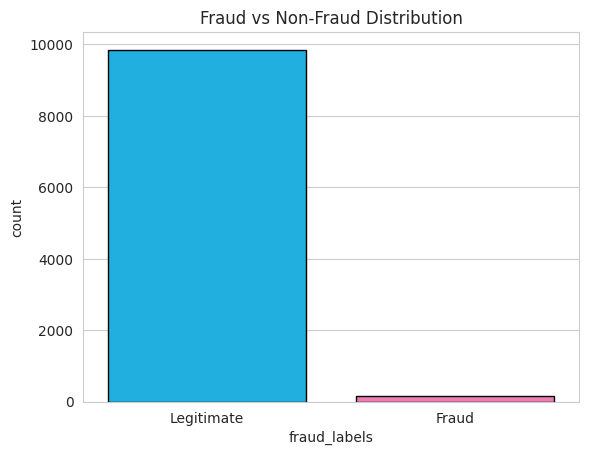

In [13]:
sns.countplot(
    x="fraud_labels",
    hue="fraud_labels",
    data=df,
    palette=["deepskyblue", "hotpink"],
    edgecolor="k",
)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


In [14]:
print(f"Total number of transactions: {len(df)}")
print(f"Total number of fraud cases: {len(df[df.is_fraud == 1])}")
print(f"Percentage of fraud cases: {df.is_fraud.mean(): .2%}")

Total number of transactions: 10000
Total number of fraud cases: 148
Percentage of fraud cases:  1.48%


## Section 5 - Numerical Feature Distribution

In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

numerical_cols.remove("is_fraud")
numerical_cols

['amount', 'lat', 'lon']

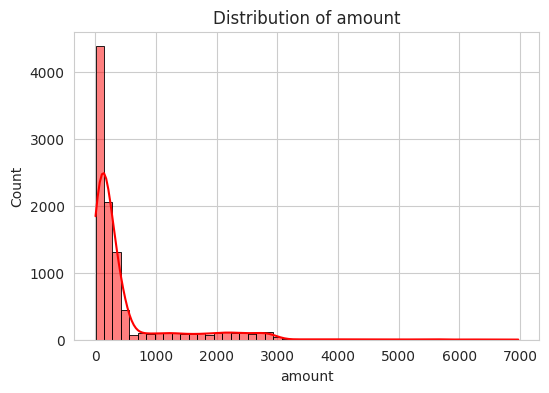

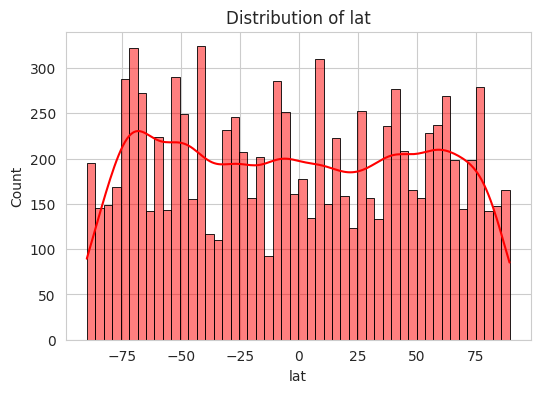

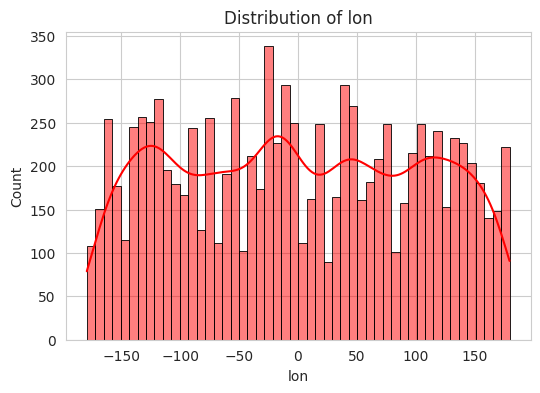

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=50, kde=True, color="r", edgecolor="k")
    plt.title(f"Distribution of {col}")
    plt.show()


## Section 6 - Fraud vs Non-Fraud Comparison

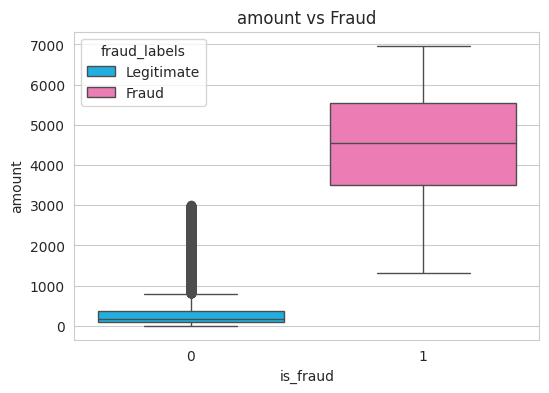

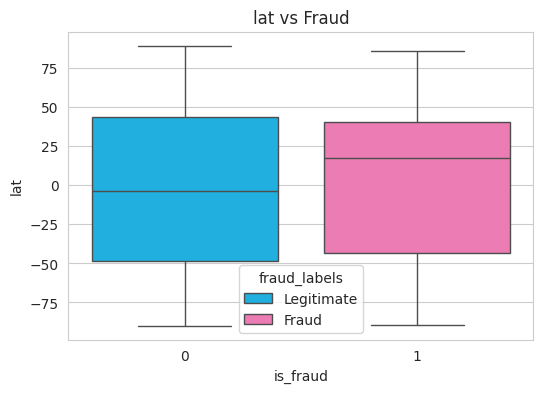

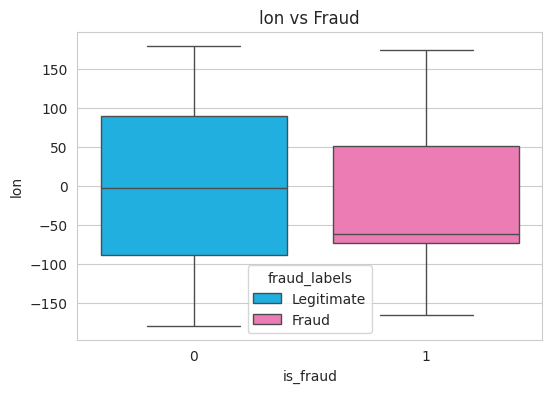

In [17]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        x="is_fraud",
        hue="fraud_labels",
        y=col,
        data=df,
        palette=["deepskyblue", "hotpink"],
    )
    plt.title(f"{col} vs Fraud")
    plt.show()


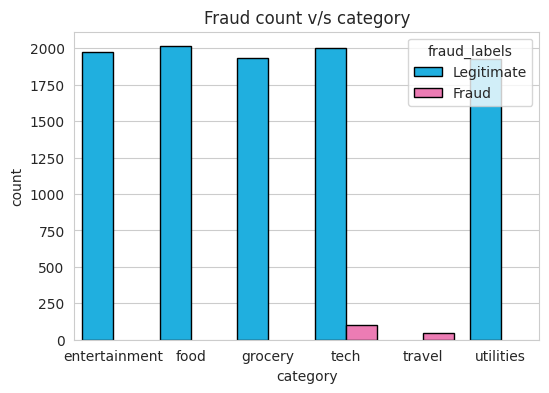

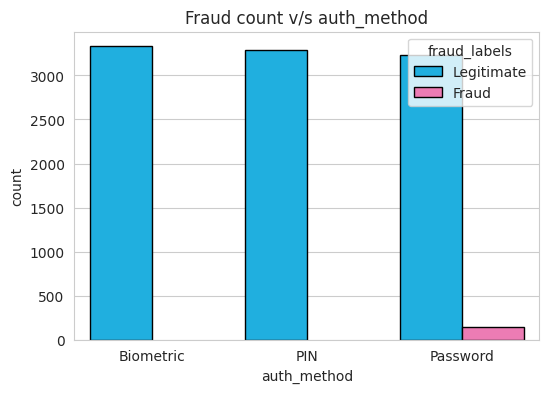

In [18]:
cat_columns = df.select_dtypes(include=["category"]).columns

for col in cat_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        x=col,
        hue="fraud_labels",
        data=df,
        palette=["deepskyblue", "hotpink"],
        edgecolor="k",
    )

    plt.title(f"Fraud count v/s {col}")
    plt.show()
    plt.close()

- **Travel `category` and password `auth_method` are the best, while predicting fraud.**

## Section 7 - Identifier Analysis

In [ ]:
df_fraud = df[df["is_fraud"] == 1]
df_leg = df[df["is_fraud"] == 0]

>***Q. How many devices are used in both legitimate and fraud transactions ?***

In [ ]:
fraud_devices = df_fraud["device_id"].unique()
df_leg[df_leg["device_id"].isin(fraud_devices)]["device_id"].nunique()

137

>***Q. How many users are affected by fraud ?***

In [20]:
df_fraud["user_id"].nunique()

126

>***Q. Number of ip address involve in fraud and legitimate transactions ?***

In [ ]:
fraud_ip_address = df_fraud["ip_address"].unique()
df_leg[df_leg["ip_address"].isin(fraud_devices)]["ip_address"].nunique()

0

- **There is no overlap of IP addresses between fraud and legitimate transactions. `ip_address` will create leakage.**

>***Q. How many users are repeat victims of fraud, and how frequently are they targeted ?***

In [ ]:
df_fraud["user_id"].value_counts().value_counts().sort_index()

count
1    105
2     20
3      1
Name: count, dtype: int64

>***Q. What is the fraud rate per user ?***

In [ ]:
df.groupby("user_id")["is_fraud"].mean().sort_values(ascending=False)[:5]

user_id
user_305    0.142857
user_419    0.133333
user_61     0.130435
user_463    0.117647
user_41     0.117647
Name: is_fraud, dtype: float64

>***Q. How frequently a device getting reused to commit fraud ?***

In [24]:
df_fraud["device_id"].value_counts().value_counts().sort_index()

count
1    126
2     11
Name: count, dtype: int64

>***Q. What is the rate of fraud per device ?***

In [36]:
df.groupby("device_id")["is_fraud"].mean().sort_values(ascending=False)[:5]


device_id
e03635fc    0.333333
a4bbf962    0.333333
3712f2d1    0.285714
60a399d4    0.250000
5f59fb4d    0.250000
Name: is_fraud, dtype: float64

>***Q. What is the rate of fraud per ip address ?***

In [35]:
df.groupby("ip_address")["is_fraud"].mean().sort_values(ascending=False)[:5]


ip_address
196.162.67.191     1.0
46.198.253.213     1.0
105.69.112.164     1.0
189.144.101.30     1.0
219.113.206.223    1.0
Name: is_fraud, dtype: float64

>***Q. Do fraud transactions cluster geographically ?***

In [ ]:
df_fraud.groupby(["lat", "lon"])["is_fraud"].agg("count").sort_values(ascending=False)[
    :5
]

lat         lon        
 40.712800  -74.006000     45
-89.811959   141.569153     1
-87.787583   123.825765     1
-89.528990   127.560176     1
-84.130938   32.529921      1
Name: is_fraud, dtype: int64

- **`40.712800,  -74.006000` is a fraud cluster.**

## Section 8 - Time Analysis

In [28]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.weekday


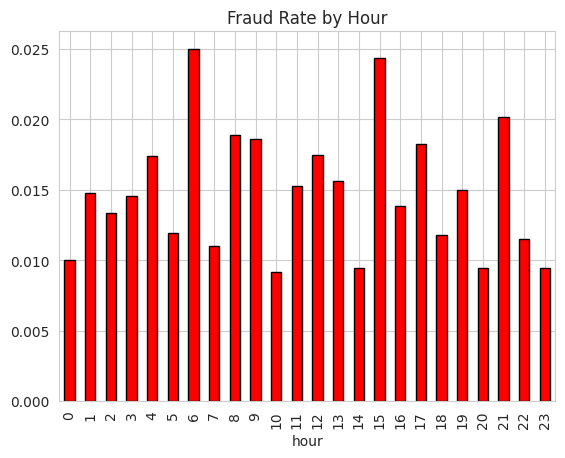

In [29]:
fraud_rate_by_hour = df.groupby("hour")["is_fraud"].mean()

fraud_rate_by_hour.plot(kind="bar", color="r", edgecolor="k")
plt.title("Fraud Rate by Hour")
plt.show()


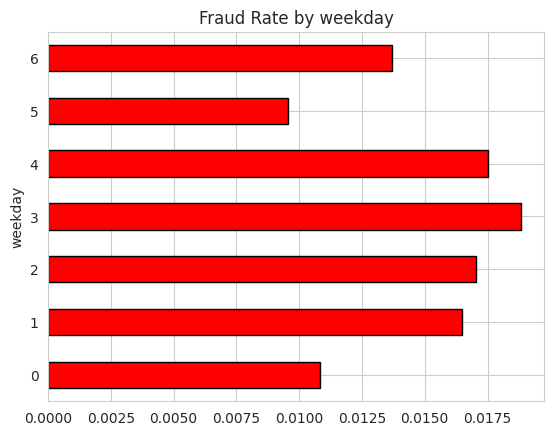

In [30]:
fraud_rate_by_hour = df.groupby("weekday")["is_fraud"].mean()

fraud_rate_by_hour.plot(kind="barh", color="r", edgecolor="k")
plt.title("Fraud Rate by weekday")
plt.show()

## Section 9 - Correlation Analysis

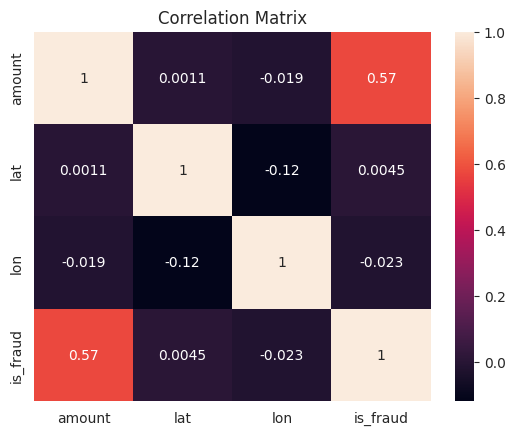

In [ ]:
plt.figure()
sns.heatmap(df[numerical_cols + ["is_fraud"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Section 10 - Quick Feature Importance Test(Numerical columns only)

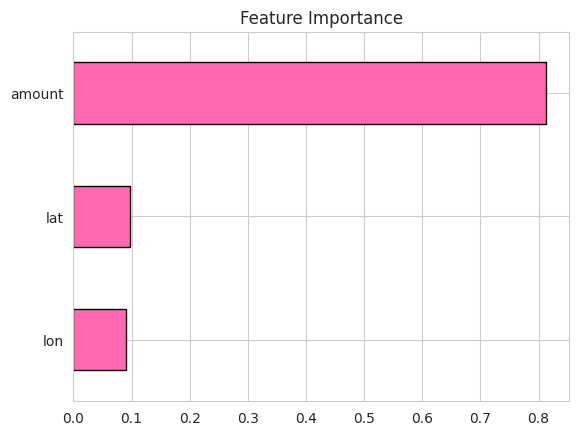

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df[numerical_cols]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind="barh", color="hotpink", edgecolor="k")
plt.title("Feature Importance")
plt.show()


# **Conclusion on dataset: simulated_transactions_seed_42.csv**

- The dataset has a very high class imbalance **1.48%**. We need to use algorithms like `xgboost` or `random forest` that has the hyperparameter to handle such imbalances.
- The feature `ip_address` is showing leakage, including this in model training only results in a weaker model. It should be dropped.
- Located a fraud cluster at `40.712800,  -74.006000`.